In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

OUTPUT_DIR = Path("../outputs")

holdout_features = pd.read_parquet(
    OUTPUT_DIR / "holdout_features.parquet"
)

graph_result = pd.read_csv(
    OUTPUT_DIR / "anomaly_graph_score.csv"
)

print("holdout_features:", holdout_features.shape)
print("graph_result:", graph_result.shape)

holdout_features: (20000, 119)
graph_result: (20000, 11)


In [20]:
# Base table for clustering
cluster_base = holdout_features.copy()

# Candidate features for persona clustering
cluster_feature_candidates = [
    # Device
    "num_imeis_90d",
    "max_customers_per_imei",
    "shared_imei_flag",
    "high_shared_imei_flag",
    "rooted_session_ratio",
    "is_rooted",
    "emulator_session_ratio",
    "is_emulator",
    "is_generic_or_clone",
    "is_feature_phone",
    "low_tier_session_ratio",
    "low_tier_device_flag",
    "tac_grey_clone_flag",
    "tac_risk_score",

    # SIM
    "sim_swap_count_90d",
    "sim_swap_count_12m",
    "days_since_last_sim_swap",
    "recent_sim_change_flag",
    "iccid_count",
    "phone_number_age_days",
    "port_in_flag",

    # Behavior
    "distinct_ip_30d",
    "distinct_country_30d",
    "datacenter_ratio_30d",
    "vpn_proxy_ratio_30d",
    "non_residential_ratio_30d",
    "home_cell_ratio_30d",
    "night_session_ratio_30d",
    "geo_velocity_alerts_30d",
    "geo_velocity_flag_30d",
    "active_days_30d",
    "total_sessions_30d",
    "avg_sessions_per_day_30d",

    # Identity
    "kyc_level_ord",
    "has_face_score",
    "has_iddoc_score",
    "face_match_score",
    "id_doc_match_score",
]

# Keep only columns that exist
cluster_feature_cols = [
    col for col in cluster_feature_candidates
    if col in cluster_base.columns
]

missing_cluster_cols = [
    col for col in cluster_feature_candidates
    if col not in cluster_base.columns
]

print("Number of clustering features:", len(cluster_feature_cols))
print("Missing candidate features:", missing_cluster_cols)

Number of clustering features: 38
Missing candidate features: []


In [21]:
X_cluster_raw = cluster_base[cluster_feature_cols].copy()

print("X_cluster_raw shape:", X_cluster_raw.shape)

X_cluster_raw.head()

X_cluster_raw shape: (20000, 38)


,num_imeis_90d,max_customers_per_imei,shared_imei_flag,high_shared_imei_flag,rooted_session_ratio,is_rooted,emulator_session_ratio,is_emulator,is_generic_or_clone,is_feature_phone,...,geo_velocity_alerts_30d,geo_velocity_flag_30d,active_days_30d,total_sessions_30d,avg_sessions_per_day_30d,kyc_level_ord,has_face_score,has_iddoc_score,face_match_score,id_doc_match_score
0,2,1,0,0,0.0,0,0.0,0,0,0,...,0.0,0.0,7.0,7.0,1.000000,1,0,1,0.000,0.896
1,1,1,0,0,0.0,0,0.0,0,0,0,...,0.0,0.0,8.0,9.0,1.125000,2,1,1,0.855,0.869
2,1,3,1,0,0.0,0,0.0,0,0,1,...,0.0,0.0,5.0,5.0,1.000000,2,1,1,0.721,0.864
3,1,1,0,0,0.0,0,0.0,0,0,0,...,0.0,0.0,6.0,7.0,1.166667,2,1,1,0.972,0.989
4,1,1,0,0,0.0,0,0.0,0,0,0,...,0.0,0.0,6.0,7.0,1.166667,2,1,1,1.000,0.985


In [22]:
missing_rate = (
    X_cluster_raw
    .isna()
    .mean()
    .sort_values(ascending=False)
)

missing_rate[missing_rate > 0]

Series([], dtype: float64)

In [23]:
binary_cols = [
    "shared_imei_flag",
    "high_shared_imei_flag",
    "is_rooted",
    "is_emulator",
    "is_generic_or_clone",
    "is_feature_phone",
    "low_tier_device_flag",
    "tac_grey_clone_flag",
    "recent_sim_change_flag",
    "port_in_flag",
    "geo_velocity_flag_30d",
    "has_face_score",
    "has_iddoc_score",
]

count_cols = [
    "num_imeis_90d",
    "max_customers_per_imei",
    "sim_swap_count_90d",
    "sim_swap_count_12m",
    "iccid_count",
    "distinct_ip_30d",
    "distinct_country_30d",
    "geo_velocity_alerts_30d",
    "active_days_30d",
    "total_sessions_30d",
    "avg_sessions_per_day_30d",
]

day_cols = [
    "days_since_last_sim_swap",
    "phone_number_age_days",
]

continuous_cols = [
    "rooted_session_ratio",
    "emulator_session_ratio",
    "low_tier_session_ratio",
    "tac_risk_score",
    "datacenter_ratio_30d",
    "vpn_proxy_ratio_30d",
    "non_residential_ratio_30d",
    "home_cell_ratio_30d",
    "night_session_ratio_30d",
    "kyc_level_ord",
    "face_match_score",
    "id_doc_match_score",
]

binary_cols = [col for col in binary_cols if col in cluster_feature_cols]
count_cols = [col for col in count_cols if col in cluster_feature_cols]
day_cols = [col for col in day_cols if col in cluster_feature_cols]
continuous_cols = [col for col in continuous_cols if col in cluster_feature_cols]

print("binary:", len(binary_cols), binary_cols)
print("count:", len(count_cols), count_cols)
print("day:", len(day_cols), day_cols)
print("continuous:", len(continuous_cols), continuous_cols)

all_typed_cols = binary_cols + count_cols + day_cols + continuous_cols

missing_typed = sorted(set(cluster_feature_cols) - set(all_typed_cols))
missing_typed

binary: 13 ['shared_imei_flag', 'high_shared_imei_flag', 'is_rooted', 'is_emulator', 'is_generic_or_clone', 'is_feature_phone', 'low_tier_device_flag', 'tac_grey_clone_flag', 'recent_sim_change_flag', 'port_in_flag', 'geo_velocity_flag_30d', 'has_face_score', 'has_iddoc_score']
count: 11 ['num_imeis_90d', 'max_customers_per_imei', 'sim_swap_count_90d', 'sim_swap_count_12m', 'iccid_count', 'distinct_ip_30d', 'distinct_country_30d', 'geo_velocity_alerts_30d', 'active_days_30d', 'total_sessions_30d', 'avg_sessions_per_day_30d']
day: 2 ['days_since_last_sim_swap', 'phone_number_age_days']
continuous: 12 ['rooted_session_ratio', 'emulator_session_ratio', 'low_tier_session_ratio', 'tac_risk_score', 'datacenter_ratio_30d', 'vpn_proxy_ratio_30d', 'non_residential_ratio_30d', 'home_cell_ratio_30d', 'night_session_ratio_30d', 'kyc_level_ord', 'face_match_score', 'id_doc_match_score']


[]

In [24]:
X_cluster_processed_parts = []

if binary_cols:
    X_binary = X_cluster_raw[binary_cols].copy()
    X_binary = X_binary.fillna(0)
    X_cluster_processed_parts.append(X_binary)

if count_cols:
    X_count = X_cluster_raw[count_cols].copy()
    
    for col in count_cols:
        X_count[col] = np.log1p(X_count[col])
    
    count_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )
    
    X_count_scaled = pd.DataFrame(
        count_pipeline.fit_transform(X_count),
        columns=count_cols,
        index=X_count.index,
    )
    
    X_cluster_processed_parts.append(X_count_scaled)

if day_cols:
    X_day = X_cluster_raw[day_cols].copy()
    
    for col in day_cols:
        upper = X_day[col].quantile(0.99)
        X_day[col] = X_day[col].clip(upper=upper)
        X_day[col] = np.log1p(X_day[col])
    
    day_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )
    
    X_day_scaled = pd.DataFrame(
        day_pipeline.fit_transform(X_day),
        columns=day_cols,
        index=X_day.index,
    )
    
    X_cluster_processed_parts.append(X_day_scaled)

if continuous_cols:
    X_cont = X_cluster_raw[continuous_cols].copy()
    
    cont_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )
    
    X_cont_scaled = pd.DataFrame(
        cont_pipeline.fit_transform(X_cont),
        columns=continuous_cols,
        index=X_cont.index,
    )
    
    X_cluster_processed_parts.append(X_cont_scaled)

X_cluster_df = pd.concat(X_cluster_processed_parts, axis=1)

X_cluster = X_cluster_df.values

X_cluster_df.shape

(20000, 38)

In [25]:
X_cluster_df.describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].sort_values("max", ascending=False).head(20)

,mean,std,min,25%,50%,75%,max
avg_sessions_per_day_30d,0.502416,0.811425,-7.272541,0.000000,0.0,1.000000,9.613776
tac_risk_score,-0.134550,0.874462,-1.000000,-1.000000,0.0,0.000000,5.000000
distinct_ip_30d,-0.063919,0.810185,-3.969362,-0.550340,0.0,0.449660,2.709511
iccid_count,0.315011,0.518393,0.000000,0.000000,0.0,1.000000,2.709511
active_days_30d,-0.236315,0.765977,-4.140202,-0.715893,0.0,0.284107,2.531010
night_session_ratio_30d,0.075166,0.670864,-0.600000,-0.600000,0.0,0.400000,2.400000
sim_swap_count_12m,0.309745,0.503348,0.000000,0.000000,0.0,1.000000,2.321928
total_sessions_30d,-0.054869,0.653216,-3.310572,-0.572439,0.0,0.427561,2.296627
geo_velocity_alerts_30d,0.020644,0.124947,0.000000,0.000000,0.0,0.000000,1.609438
max_customers_per_imei,0.033594,0.153437,0.000000,0.000000,0.0,0.000000,1.504077


In [26]:
k_range = range(3, 9)

kmeans_results = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=20,
    )

    labels = kmeans.fit_predict(X_cluster)

    sil = silhouette_score(
        X_cluster,
        labels,
        sample_size=min(5000, X_cluster.shape[0]),
        random_state=42,
    )

    cluster_sizes = pd.Series(labels).value_counts(normalize=True)

    kmeans_results.append(
        {
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette": sil,
            "largest_cluster_pct": cluster_sizes.max(),
            "smallest_cluster_pct": cluster_sizes.min(),
        }
    )

kmeans_eval = pd.DataFrame(kmeans_results)

kmeans_eval

,k,inertia,silhouette,largest_cluster_pct,smallest_cluster_pct
0,3,135382.859017,0.183413,0.55530,0.10235
1,4,123410.002473,0.180874,0.39540,0.10230
2,5,114862.065505,0.190382,0.36260,0.10230
3,6,108609.606561,0.170932,0.22805,0.10230
4,7,104758.517731,0.174739,0.21045,0.06470
5,8,101309.509529,0.186000,0.20695,0.06430


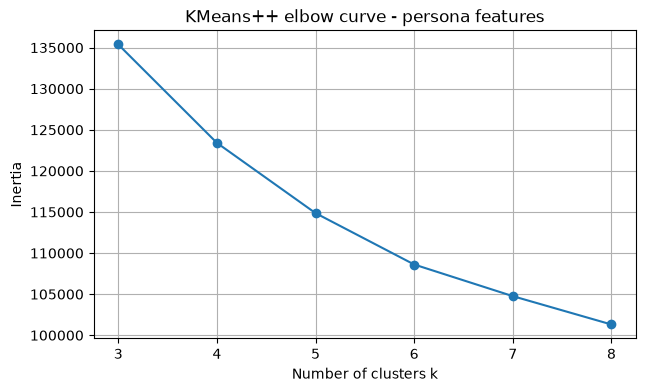

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(kmeans_eval["k"], kmeans_eval["inertia"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("KMeans++ elbow curve - persona features")
plt.grid(True)
plt.show()

In [28]:
best_k = 4

kmeans_final = KMeans(
    n_clusters=best_k,
    init="k-means++",
    random_state=42,
    n_init=20,
)

cluster_labels = kmeans_final.fit_predict(X_cluster)

cluster_result = pd.DataFrame({
    "CustomerID": holdout_features["CustomerID"],
    "cluster_id": cluster_labels,
})

cluster_result.head()

,CustomerID,cluster_id
0,3000006,2
1,3000018,2
2,3000034,2
3,3000070,0
4,3000074,0


In [29]:
cluster_size = (
    cluster_result["cluster_id"]
    .value_counts()
    .sort_index()
    .rename("size")
    .to_frame()
)

cluster_size["size_pct"] = cluster_size["size"] / cluster_size["size"].sum()

cluster_size

,size,size_pct
cluster_id,,
0,5761,0.28805
1,2046,0.10230
2,7908,0.39540
3,4285,0.21425


In [30]:
# Merge graph/anomaly để profile, không dùng để fit

graph_profile_cols = [
    "CustomerID",
    "anomaly_score",
    "graph_adjusted_anomaly_score",
    "neighbor_count",
    "neighbor_anomaly_max",
    "neighbor_anomaly_mean",
]

graph_profile_cols = [
    col for col in graph_profile_cols
    if col in graph_result.columns
]

cluster_result = cluster_result.merge(
    graph_result[graph_profile_cols],
    on="CustomerID",
    how="left",
)

cluster_result.head()

,CustomerID,cluster_id,anomaly_score,graph_adjusted_anomaly_score,neighbor_count,neighbor_anomaly_max,neighbor_anomaly_mean
0,3000006,2,0.945000,0.914292,0,0.000000,0.000000
1,3000018,2,0.641795,0.634032,0,0.000000,0.000000
2,3000034,2,0.992230,0.995910,2,0.967645,0.771803
3,3000070,0,0.970890,0.933148,0,0.000000,0.000000
4,3000074,0,0.535140,0.530037,0,0.000000,0.000000


In [31]:
cluster_profile_df = holdout_features.merge(
    cluster_result,
    on="CustomerID",
    how="left",
)

cluster_profile_df.shape

(20000, 125)

In [32]:
cluster_summary = (
    cluster_profile_df
    .groupby("cluster_id")
    .agg(
        size=("CustomerID", "count"),
        anomaly_mean=("anomaly_score", "mean"),
        graph_anomaly_mean=("graph_adjusted_anomaly_score", "mean"),
        anomaly_p90=("graph_adjusted_anomaly_score", lambda x: x.quantile(0.90)),
        neighbor_count_mean=("neighbor_count", "mean"),
        neighbor_anomaly_max_mean=("neighbor_anomaly_max", "mean"),
    )
    .reset_index()
)

cluster_summary["size_pct"] = (
    cluster_summary["size"] / cluster_summary["size"].sum()
)

cluster_summary.sort_values("graph_anomaly_mean", ascending=False)

,cluster_id,size,anomaly_mean,graph_anomaly_mean,anomaly_p90,neighbor_count_mean,neighbor_anomaly_max_mean,size_pct
1,1,2046,0.629231,0.624739,0.916453,0.500000,0.109696,0.10230
2,2,7908,0.497155,0.497533,0.864270,0.321826,0.083846,0.39540
3,3,4285,0.480619,0.480473,0.848574,0.222870,0.062057,0.21425
0,0,5761,0.472512,0.473697,0.847543,0.287277,0.081357,0.28805


In [33]:
profile_cols = cluster_feature_cols.copy()

cluster_feature_profile = (
    cluster_profile_df
    .groupby("cluster_id")[profile_cols]
    .mean()
    .reset_index()
)

cluster_feature_profile

,cluster_id,num_imeis_90d,max_customers_per_imei,shared_imei_flag,high_shared_imei_flag,rooted_session_ratio,is_rooted,emulator_session_ratio,is_emulator,is_generic_or_clone,...,geo_velocity_alerts_30d,geo_velocity_flag_30d,active_days_30d,total_sessions_30d,avg_sessions_per_day_30d,kyc_level_ord,has_face_score,has_iddoc_score,face_match_score,id_doc_match_score
0,0,1.022392,1.078285,0.047908,0.002083,0.017879,0.017879,0.000000,0.000000,0.000000,...,0.035584,0.031071,6.202048,6.903663,1.118473,1.603194,0.603194,1.000000,0.545994,0.924854
1,1,1.090909,1.203812,0.079179,0.025415,0.039589,0.039589,0.062195,0.068915,0.072825,...,0.031769,0.028837,5.574780,6.155914,1.100878,0.016129,0.003910,0.012219,0.003495,0.004445
2,2,1.120890,1.102175,0.053237,0.008093,0.027820,0.027820,0.125501,0.137962,0.138341,...,0.040971,0.035534,6.602934,7.390870,1.127339,1.599267,0.599267,1.000000,0.542344,0.925100
3,3,1.092882,1.080047,0.044107,0.004901,0.015403,0.015403,0.039308,0.043874,0.072345,...,0.008168,0.007935,3.171995,3.316919,1.044635,1.604667,0.604667,1.000000,0.547234,0.924493


In [ ]:
global_mean = cluster_profile_df[profile_cols].mean()

cluster_lift = (
    cluster_profile_df
    .groupby("cluster_id")[profile_cols]
    .mean()
    .div(global_mean.replace(0, np.nan))
)

cluster_lift = cluster_lift.replace([np.inf, -np.inf], np.nan)

cluster_lift

,num_imeis_90d,max_customers_per_imei,shared_imei_flag,high_shared_imei_flag,rooted_session_ratio,is_rooted,emulator_session_ratio,is_emulator,is_generic_or_clone,is_feature_phone,...,geo_velocity_alerts_30d,geo_velocity_flag_30d,active_days_30d,total_sessions_30d,avg_sessions_per_day_30d,kyc_level_ord,has_face_score,has_iddoc_score,face_match_score,id_doc_match_score
cluster_id,,,,,,,,,,,,,,,,,,,,,
0,0.943645,0.979413,0.914281,0.279594,0.760802,0.760802,0.000000,0.000000,0.000000,0.000000,...,1.131450,1.123725,1.098252,1.104347,1.012780,1.113638,1.115683,1.112409,1.115825,1.113322
1,1.006885,1.093431,1.511047,3.411469,1.684657,1.684657,0.965651,0.970633,0.937863,0.950872,...,1.010153,1.042921,0.987176,0.984734,0.996848,0.011204,0.007232,0.013592,0.007142,0.005351
2,1.034556,1.001113,1.015978,1.086318,1.183827,1.183827,1.948549,1.943121,1.781596,1.607205,...,1.302740,1.285122,1.169240,1.182284,1.020809,1.110910,1.108419,1.112409,1.108365,1.113617
3,1.008706,0.981013,0.841743,0.657828,0.655428,0.655428,0.610303,0.617943,0.931686,1.247313,...,0.259715,0.286968,0.561693,0.530593,0.945920,1.114662,1.118408,1.112409,1.118360,1.112886


In [35]:
for cid in sorted(cluster_lift.index):
    print(f"\nCluster {cid}")
    display(
        cluster_lift
        .loc[cid]
        .sort_values(ascending=False)
        .head(12)
        .to_frame("lift")
    )


Cluster 0


,lift
geo_velocity_alerts_30d,1.131450
geo_velocity_flag_30d,1.123725
face_match_score,1.115825
has_face_score,1.115683
kyc_level_ord,1.113638
id_doc_match_score,1.113322
has_iddoc_score,1.112409
total_sessions_30d,1.104347
active_days_30d,1.098252
distinct_ip_30d,1.092437



Cluster 1


,lift
high_shared_imei_flag,3.411469
rooted_session_ratio,1.684657
is_rooted,1.684657
vpn_proxy_ratio_30d,1.665424
non_residential_ratio_30d,1.562017
shared_imei_flag,1.511047
datacenter_ratio_30d,1.491550
max_customers_per_imei,1.093431
tac_grey_clone_flag,1.045627
geo_velocity_flag_30d,1.042921



Cluster 2


,lift
emulator_session_ratio,1.948549
is_emulator,1.943121
tac_grey_clone_flag,1.836627
is_generic_or_clone,1.781596
tac_risk_score,1.672857
low_tier_device_flag,1.622505
low_tier_session_ratio,1.621940
is_feature_phone,1.607205
geo_velocity_alerts_30d,1.302740
geo_velocity_flag_30d,1.285122



Cluster 3


,lift
is_feature_phone,1.247313
low_tier_session_ratio,1.212873
low_tier_device_flag,1.211554
has_face_score,1.118408
face_match_score,1.118360
kyc_level_ord,1.114662
id_doc_match_score,1.112886
has_iddoc_score,1.112409
tac_risk_score,1.069179
phone_number_age_days,1.029963
